# ITM Basket + CBA (TSLA vs TSLL per leg) -- Sandbox

Extends `itm_basket_sandbox.ipynb`: for each leg, pick whichever underlying
(TSLA or TSLL) gives the cheapest delta-neutral fill -- same CBA logic as production
`simulate_ensemble`, applied per basket leg.

TSLL fill rates in the sim window (60-110 DTE, px_volume>0):
- 20% ITM: ~34%  |  10% ITM: ~47%  |  ATM: ~50%  |  10%OTM: ~49%  |  20%OTM: ~45%

TSLL won't fill every roll, but when it does it's cheaper (lower underlying price →
lower option premium for same delta-neutral sizing). Falls back to TSLA when no TSLL fill.

**Baseline:** single-leg 10%OTM, CBA (TSLA or TSLL) -- matches the production ensemble context.  
**Baskets:** all 6 compositions from the ITM basket test + CBA per leg.  
**Fixed:** 10%OTM/90d/roll@5d, frictionless, calendar roll only.  
**Ranked by Max DD.**

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls, load_tsll_calls
from options_selection import select_contract, bs_delta, MONEYNESS_RANGES
from metrics import summarize
from cba_backtest import _position_cost

# Add ITM buckets locally -- no production files touched
MONEYNESS_RANGES["10% ITM"] = (0.85, 0.95)
MONEYNESS_RANGES["20% ITM"] = (0.75, 0.85)

%matplotlib inline

tsll_df    = load_tsll()
r_tsll     = tsll_df.set_index("Date")["Close"].pct_change().dropna()
returns    = r_tsll.rename("TSLL").to_frame()

tsla_spot  = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()
tsll_spot  = tsll_df.set_index("Date")["Close"].reindex(returns.index).ffill()

tsla_calls = load_tsla_calls()
tsll_calls = load_tsll_calls()

tsla_lut   = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsll_lut   = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

tsla_sigma = (tsla_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()
tsll_sigma = (tsll_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()

print(f"{len(returns):,} trading days  {returns.index.min().date()} -> {returns.index.max().date()}")
print("Data loaded.")

962 trading days  2022-08-10 -> 2026-06-10
Data loaded.


In [2]:
TARGET_DTE = 90
MAX_DTE    = 110
ROLL_DTE   = 5
TSLL_LEVER = 2.0
R_RF       = 0.05

FALLBACK = {
    "20% ITM": ["10% ITM", "ATM"],
    "10% ITM": ["ATM"],
    "ATM":     ["10% OTM"],
    "10% OTM": ["ATM"],
    "20% OTM": ["10% OTM", "ATM"],
}

COMPOSITIONS = {
    "Baseline (single 10%OTM, CBA)": ["10% OTM"],
    "A: ATM+10%OTM+20%OTM":          ["ATM", "10% OTM", "20% OTM"],
    "B: 10%ITM+ATM+10%OTM":          ["10% ITM", "ATM", "10% OTM"],
    "C: 10%ITM+ATM+10%OTM+20%OTM":  ["10% ITM", "ATM", "10% OTM", "20% OTM"],
    "D: 10%ITM+10%OTM+20%OTM":      ["10% ITM", "10% OTM", "20% OTM"],
    "E: 20%ITM+10%ITM+ATM+10%OTM":  ["20% ITM", "10% ITM", "ATM", "10% OTM"],
    "F: 20%ITM+10%ITM+ATM":         ["20% ITM", "10% ITM", "ATM"],
}

print(f"target_dte={TARGET_DTE}  roll_dte={ROLL_DTE}  frictionless  CBA per leg (TSLA vs TSLL)")
print(f"{len(COMPOSITIONS)} compositions")

target_dte=90  roll_dte=5  frictionless  CBA per leg (TSLA vs TSLL)
7 compositions


In [3]:
def _cba_leg(d, bucket, cum_val):
    """
    For one basket leg, try both TSLA and TSLL (and their fallback chains).
    Return the position dict for whichever underlying is cheaper, or None.
    """
    sig_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
    sig_b = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5

    best_cost = float("inf")
    best_pos  = None

    for bucket_try in [bucket] + FALLBACK.get(bucket, []):
        # TSLA leg
        row_a = select_contract(tsla_calls, tsla_spot, d, bucket_try, TARGET_DTE, max_dte=MAX_DTE)
        cost_a, n_a, entry_a = _position_cost(row_a, tsla_spot.loc[d], sig_a, TSLL_LEVER, cum_val, d)
        if row_a is not None and cost_a < best_cost:
            best_cost = cost_a
            best_pos  = {"ul": "tsla", "raw_id": row_a["raw_id"],
                         "strike": float(row_a["strike"]), "expiry": row_a["expiry"],
                         "n": n_a, "price": entry_a}

        # TSLL leg
        row_b = select_contract(tsll_calls, tsll_spot, d, bucket_try, TARGET_DTE, max_dte=MAX_DTE)
        cost_b, n_b, entry_b = _position_cost(row_b, tsll_spot.loc[d], sig_b, 1.0, cum_val, d)
        if row_b is not None and cost_b < best_cost:
            best_cost = cost_b
            best_pos  = {"ul": "tsll", "raw_id": row_b["raw_id"],
                         "strike": float(row_b["strike"]), "expiry": row_b["expiry"],
                         "n": n_b, "price": entry_b}

        if best_pos is not None:
            break   # found a fill at this bucket -- no need to try further fallbacks

    return best_pos


def simulate_basket_cba(returns, basket_buckets):
    """
    Short $1 TSLL + simultaneous basket of calls.
    Each leg: CBA selection (cheapest of TSLA or TSLL call).
    Roll when earliest-expiring leg hits ROLL_DTE.
    """
    n_legs      = len(basket_buckets)
    cum_tsll    = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity      = pd.Series(index=returns.index, dtype=float)
    positions   = {b: None for b in basket_buckets}
    option_pnl  = 0.0
    n_misses    = 0
    tsll_fills  = 0
    tsla_fills  = 0

    def mtm(pos, d):
        lut  = tsla_lut if pos["ul"] == "tsla" else tsll_lut
        spot = tsla_spot if pos["ul"] == "tsla" else tsll_spot
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    for d in returns.index:
        held_dtes = [(positions[b]["expiry"] - d).days
                     if positions[b] is not None else -1
                     for b in basket_buckets]
        need_roll = any(positions[b] is None for b in basket_buckets) \
                    or min(held_dtes) < ROLL_DTE

        if need_roll:
            for b in basket_buckets:
                if positions[b] is not None:
                    option_pnl += positions[b]["n"] * 100 * (
                        mtm(positions[b], d) - positions[b]["price"])

            cum_val = float(cum_tsll.loc[d])
            # each leg gets 1/N of the total target dollar-delta
            # _cba_leg uses TSLL_LEVER/1.0 internally; scale n down by n_legs here
            new_positions = {}
            for b in basket_buckets:
                pos = _cba_leg(d, b, cum_val / n_legs)
                if pos is None:
                    n_misses += 1
                else:
                    if pos["ul"] == "tsll": tsll_fills += 1
                    else:                   tsla_fills += 1
                new_positions[b] = pos
            positions = new_positions

        else:
            for b in basket_buckets:
                if positions[b] is not None:
                    px = mtm(positions[b], d)
                    option_pnl          += positions[b]["n"] * 100 * (px - positions[b]["price"])
                    positions[b]["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    total_fills = tsla_fills + tsll_fills
    return equity, n_misses, tsll_fills, tsla_fills

In [4]:
rows   = []
curves = {}

for label, buckets in COMPOSITIONS.items():
    eq, n_miss, tsll_f, tsla_f = simulate_basket_cba(returns, buckets)
    eq = eq / eq.iloc[0]
    assert eq.isna().sum() == 0, f"{label}: NaNs"
    curves[label] = eq
    row = summarize(eq, eq.pct_change().dropna(), label)
    total_f = tsll_f + tsla_f
    row["TSLL fills"]   = f"{tsll_f} ({tsll_f/total_f*100:.0f}%)" if total_f else "0"
    row["Leg misses"]   = n_miss
    rows.append(row)
    print(f"{label:45s}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  "
          f"MaxDD={row['Max DD']:.1%}  TSLL={tsll_f/total_f*100:.0f}%")

results_df = pd.DataFrame(rows).sort_values("Max DD", ascending=False)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", None)
print()
print("=== Ranked by Max DD (best first) ===")
print(results_df[["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD",
                  "Calmar", "TSLL fills", "Leg misses"]].to_string(index=False))

Baseline (single 10%OTM, CBA)                  CAGR=+10.0%  Sharpe=0.45  MaxDD=-33.2%  TSLL=68%


A: ATM+10%OTM+20%OTM                           CAGR=+14.5%  Sharpe=0.59  MaxDD=-33.9%  TSLL=66%


B: 10%ITM+ATM+10%OTM                           CAGR=+9.8%  Sharpe=0.46  MaxDD=-34.0%  TSLL=72%


C: 10%ITM+ATM+10%OTM+20%OTM                    CAGR=+13.5%  Sharpe=0.57  MaxDD=-26.4%  TSLL=70%
D: 10%ITM+10%OTM+20%OTM                        CAGR=+14.3%  Sharpe=0.58  MaxDD=-32.2%  TSLL=65%


E: 20%ITM+10%ITM+ATM+10%OTM                    CAGR=+10.1%  Sharpe=0.47  MaxDD=-31.2%  TSLL=69%
F: 20%ITM+10%ITM+ATM                           CAGR=+10.5%  Sharpe=0.47  MaxDD=-39.2%  TSLL=70%

=== Ranked by Max DD (best first) ===
                     Strategy     CAGR  Ann. Vol   Sharpe    Max DD   Calmar TSLL fills  Leg misses
  C: 10%ITM+ATM+10%OTM+20%OTM 0.135146  0.297793 0.574628 -0.263633 0.512629   98 (70%)           0
  E: 20%ITM+10%ITM+ATM+10%OTM 0.101008  0.296434 0.471779 -0.312108 0.323630   58 (69%)           0
      D: 10%ITM+10%OTM+20%OTM 0.142868  0.319866 0.576773 -0.322288 0.443293   62 (65%)           0
Baseline (single 10%OTM, CBA) 0.099934  0.328847 0.453037 -0.331802 0.301185   13 (68%)           0
         A: ATM+10%OTM+20%OTM 0.144556  0.314638 0.585764 -0.339367 0.425958   61 (66%)           0
         B: 10%ITM+ATM+10%OTM 0.098356  0.307627 0.457814 -0.339990 0.289293   43 (72%)           0
         F: 20%ITM+10%ITM+ATM 0.105343  0.332717 0.465705 -0.391888 0

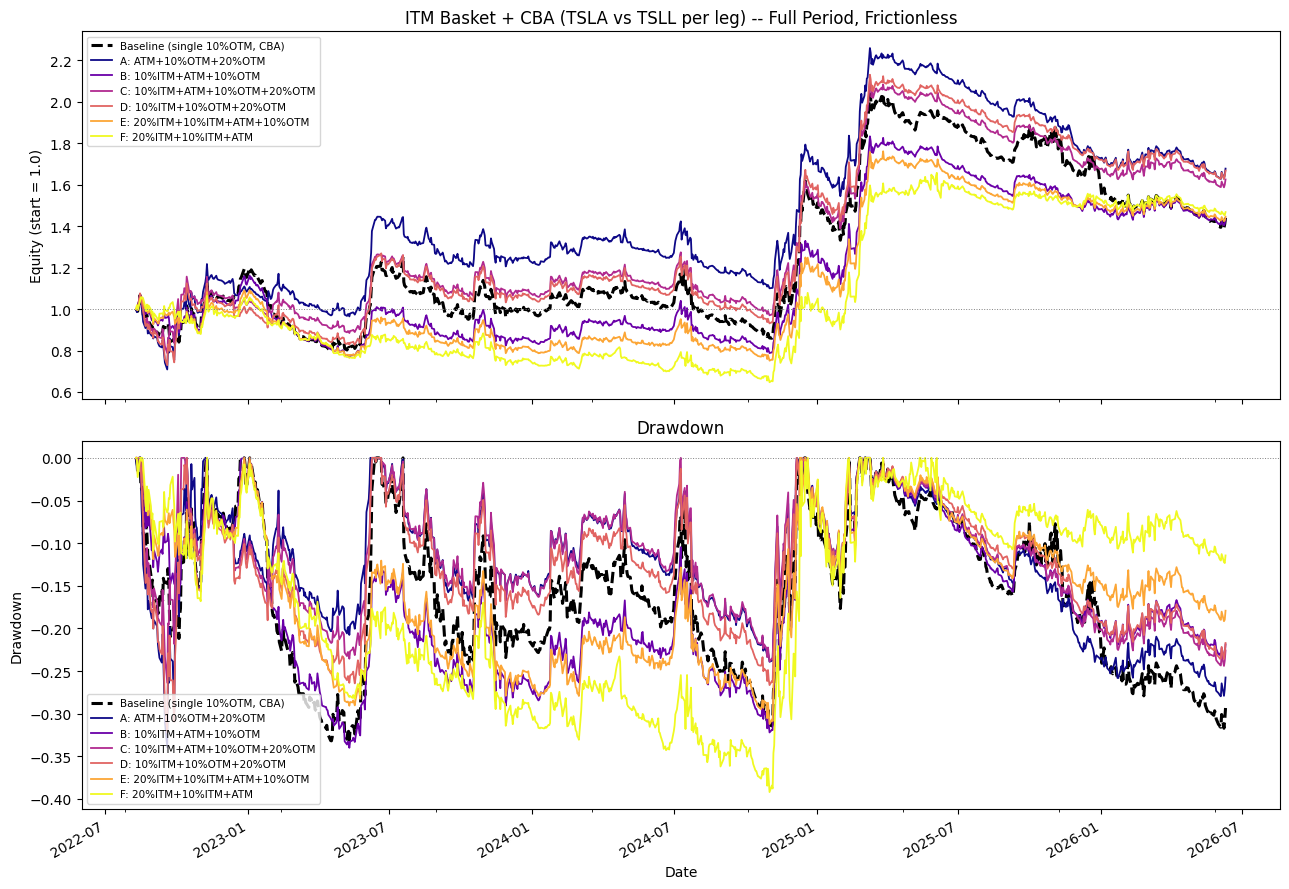

Saved: observations/strategies/sandbox/itm_basket_cba_comparison.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

non_bl = [l for l in curves if "Baseline" not in l]
colors = cm.plasma([i / max(len(non_bl)-1, 1) for i in range(len(non_bl))])

bl = "Baseline (single 10%OTM, CBA)"
curves[bl].plot(ax=axes[0], label=bl, color="black", linewidth=2.2, linestyle="--")
(curves[bl] / curves[bl].cummax() - 1).plot(ax=axes[1], label=bl, color="black",
                                              linewidth=2.2, linestyle="--")
for label, color in zip(non_bl, colors):
    curves[label].plot(ax=axes[0], label=label, color=color, linewidth=1.3)
    (curves[label] / curves[label].cummax() - 1).plot(ax=axes[1], label=label,
                                                       color=color, linewidth=1.3)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.7)
axes[0].set_title("ITM Basket + CBA (TSLA vs TSLL per leg) -- Full Period, Frictionless")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=7.5, loc="upper left")

axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=7.5, loc="lower left")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "itm_basket_cba_comparison.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")